In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import (RandomForestClassifier, HistGradientBoostingClassifier,
                              StackingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid", palette="deep")

plt.rcParams.update({
    "axes.grid": True,
    "axes.grid.which": "both",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.35,
    "grid.linewidth": 0.6,
})

In [2]:
# Крок 1. Первинний аналіз даних
# Файл уже з заголовками, але назви колонок через крапку (process.b1.capacity).
# Перейменуємо в короткий snake_case, щоб код був чистіший.
df = pd.read_csv("data.csv")
df = df.rename(columns={
    "process.b1.capacity": "b1_capacity",
    "process.b2.capacity": "b2_capacity",
    "process.b3.capacity": "b3_capacity",
    "process.b4.capacity": "b4_capacity",
    "property.price": "price",
    "property.product": "product",
    "property.winner": "winner",
    "verification.result": "result",
    "verification.time": "ver_time",
})
df.shape

(2043, 9)

In [3]:
df.head()

,b1_capacity,b2_capacity,b3_capacity,b4_capacity,price,product,winner,result,ver_time
0,0,0,2,1,59,1,0,False,163.316667
1,0,0,2,1,59,2,0,False,200.860000
2,0,0,2,1,59,4,0,False,154.888889
3,0,0,2,1,59,6,0,False,108.640000
4,0,0,2,1,60,1,0,True,85.466667


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2043 entries, 0 to 2042
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   b1_capacity  2043 non-null   int64  
 1   b2_capacity  2043 non-null   int64  
 2   b3_capacity  2043 non-null   int64  
 3   b4_capacity  2043 non-null   int64  
 4   price        2043 non-null   int64  
 5   product      2043 non-null   int64  
 6   winner       2043 non-null   int64  
 7   result       2043 non-null   bool   
 8   ver_time     2043 non-null   float64
dtypes: bool(1), float64(1), int64(7)
memory usage: 129.8 KB


In [5]:
# Перевірка пропусків
df.isna().sum()

b1_capacity    0
b2_capacity    0
b3_capacity    0
b4_capacity    0
price          0
product        0
winner         0
result         0
ver_time       0
dtype: int64

In [6]:
# Перевірка дублікатів рядків
df.duplicated().sum()

np.int64(0)

In [7]:
# Пропусків і дублікатів немає. Колонки:
# - b1_capacity..b4_capacity - місткості 4 учасників (малі цілі, порядкові);
# - price - ціна, що верифікується (числова);
# - product, winner - категоріальні (номінальні: номер продукту і номер переможця, winner=0 - верифікація лише ціни);
# - result - наш таргет (bool: здійсненний сценарій чи ні);
# - ver_time - час верифікації. За описом датасету це окремий таргет (для регресії), тому у фічі його не беремо.

In [8]:
# Скільки унікальних значень у кожній колонці (щоб побачити, де категоріальні, а де числові)
df.nunique()

b1_capacity       3
b2_capacity       4
b3_capacity       2
b4_capacity       2
price            32
product           6
winner            5
result            2
ver_time       2039
dtype: int64

result
False    1781
True      262
Name: count, dtype: int64
result
False    0.872
True     0.128
Name: proportion, dtype: float64


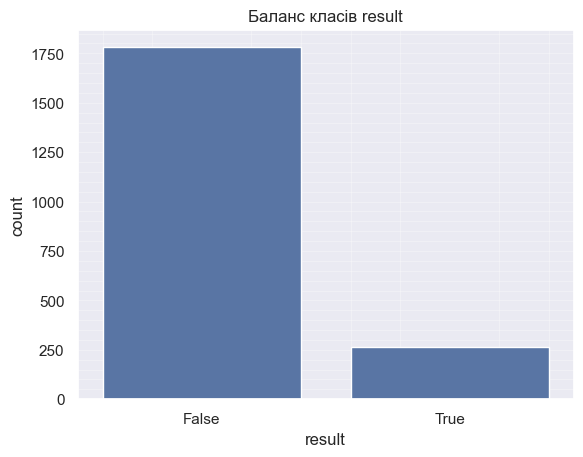

In [9]:
# Баланс таргета result
print(df["result"].value_counts())
print(df["result"].value_counts(normalize=True).round(3))

sns.countplot(x=df["result"])
plt.title("Баланс класів result")
plt.show()

In [10]:
# Датасет сильно незбалансований: ~87% False і лише ~13% True.
# Це важливо для подальших кроків:
# - accuracy буде оманливою (модель, що завжди каже False, дасть ~87%), тому дивитимемось на precision/recall/f1;
# - поділ на train/val/test робитимемо зі stratify, щоб частка True була однакова в усіх частинах.

In [11]:
# Крок 2. Фіча-інжиніринг
# Будуємо кілька кандидатів, далі виміряємо їхній сигнал і лишимо найкращі.
caps = ["b1_capacity", "b2_capacity", "b3_capacity", "b4_capacity"]

# winner_capacity: місткість того учасника, якого перевіряють як переможця
# (winner=k -> беремо b{k}_capacity; winner=0 - верифікація лише ціни, місткості немає -> 0)
def _winner_cap(row):
    w = int(row["winner"])
    return 0 if w == 0 else row[f"b{w}_capacity"]
df["winner_capacity"] = df.apply(_winner_cap, axis=1)

# total_capacity: сумарна місткість усіх учасників
df["total_capacity"] = df[caps].sum(axis=1)

# ще два кандидати - для порівняння, щоб чесно показати на графіку, що вони слабкі
df["n_active_bidders"] = (df[caps] > 0).sum(axis=1)   # скільки учасників із місткістю > 0
df["price_only"] = (df["winner"] == 0).astype(int)    # прапорець "верифікація лише ціни"

df[["winner_capacity", "total_capacity", "n_active_bidders", "price_only"]].head()

,winner_capacity,total_capacity,n_active_bidders,price_only
0,0,3,2,1
1,0,3,2,1
2,0,3,2,1
3,0,3,2,1
4,0,3,2,1


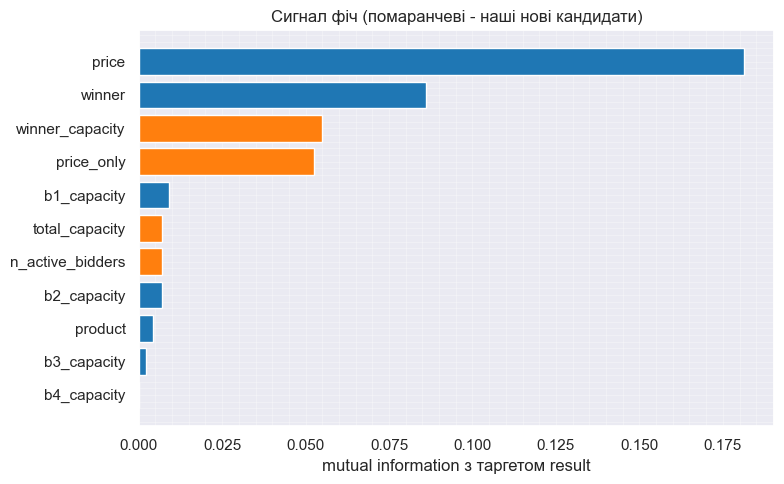

In [12]:
# Міряємо сигнал усіх фіч (вихідні + кандидати) через mutual information з таргетом.
# Mutual information показує, скільки інформації про result дає фіча (0 = нічого).
feature_cols = caps + ["price", "product", "winner",
                       "winner_capacity", "total_capacity", "n_active_bidders", "price_only"]
y = df["result"].astype(int)
mi = mutual_info_classif(df[feature_cols], y, discrete_features=True, random_state=42)
mi = pd.Series(mi, index=feature_cols).sort_values()

candidates = ["winner_capacity", "total_capacity", "n_active_bidders", "price_only"]
colors = ["tab:orange" if c in candidates else "tab:blue" for c in mi.index]
plt.figure(figsize=(8, 5))
plt.barh(mi.index, mi.values, color=colors)
plt.xlabel("mutual information з таргетом result")
plt.title("Сигнал фіч (помаранчеві - наші нові кандидати)")
plt.tight_layout()
plt.show()

In [13]:
# price і winner - найсильніші (основний сигнал у самих даних). Серед нових кандидатів
# winner_capacity помітно виділяється, а total_capacity, n_active_bidders і price_only майже
# на рівні нуля. price_only до того ж дублює майбутню one-hot колонку winner=0, тому його
# відкидаємо однозначно.

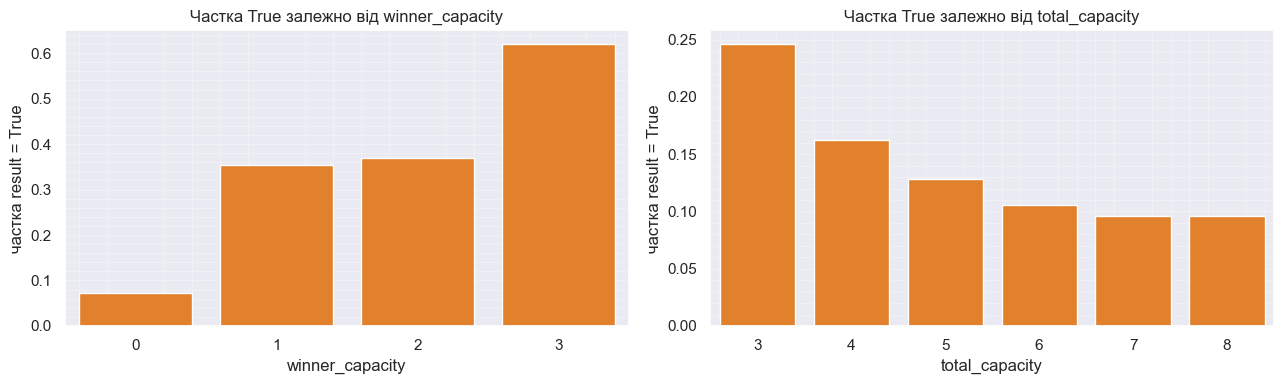

In [14]:
# Дивимось, як частка True (result) залежить від двох фіч, які вирішили лишити
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ["winner_capacity", "total_capacity"]):
    rate = df.groupby(col)["result"].mean()
    sns.barplot(x=rate.index, y=rate.values, ax=ax, color="tab:orange")
    ax.set_title(f"Частка True залежно від {col}")
    ax.set_ylabel("частка result = True")
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

In [15]:
# winner_capacity: частка True помітно різна для різних значень - фіча відрізняє здійсненні
# сценарії від нездійсненних, сигнал є. total_capacity: залежність слабша й нерівна, сигналу
# мало (це підтвердив і mutual information). Але лишаємо її як другу нову фічу - вона стискає
# місткості в одне число, що може трохи допомогти базовим моделям стекінгу; на кроці оцінки
# подивимось на feature_importances, чи справдилось.

In [16]:
# Відкидаємо кандидатів зі слабким або дубльованим сигналом, лишаємо winner_capacity + total_capacity
df = df.drop(columns=["n_active_bidders", "price_only"])
df.columns.tolist()

['b1_capacity',
 'b2_capacity',
 'b3_capacity',
 'b4_capacity',
 'price',
 'product',
 'winner',
 'result',
 'ver_time',
 'winner_capacity',
 'total_capacity']

In [17]:
# Крок 3+4. Поділ train/val/test (stratify) + препроцесинг (масштабування)
# Таргет - result; ver_time не беремо (це окремий таргет). Решта - фічі.
numeric_features = ["b1_capacity", "b2_capacity", "b3_capacity", "b4_capacity",
                    "price", "winner_capacity", "total_capacity"]
categorical_features = ["product", "winner"]
feature_cols = numeric_features + categorical_features

X = df[feature_cols]
y = df["result"].astype(int)

# Поділ 60/20/20 зі stratify - датасет незбалансований, тож частка True має бути однакова в усіх частинах
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval)
print("train:", X_train.shape[0], "| val:", X_val.shape[0], "| test:", X_test.shape[0])

train: 1225 | val: 409 | test: 409


In [18]:
# Перевіряємо, що stratify зберіг частку True в кожній частині
for name, yy in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name}: частка True = {yy.mean():.3f}")

train: частка True = 0.128
val: частка True = 0.130
test: частка True = 0.127


In [19]:
# Препроцесор: числові/порядкові -> StandardScaler, категоріальні (product, winner) -> OneHot
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
])

# fit лише на train (без витоку), val і test тільки трансформуємо
X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

feat_names = preprocessor.get_feature_names_out()
X_train_prep = pd.DataFrame(X_train_prep, columns=feat_names, index=X_train.index)
X_val_prep = pd.DataFrame(X_val_prep, columns=feat_names, index=X_val.index)
X_test_prep = pd.DataFrame(X_test_prep, columns=feat_names, index=X_test.index)

print("колонок після препроцесингу:", X_train_prep.shape[1])
X_train_prep.head()

колонок після препроцесингу: 18


,num__b1_capacity,num__b2_capacity,num__b3_capacity,num__b4_capacity,num__price,num__winner_capacity,num__total_capacity,cat__product_1,cat__product_2,cat__product_3,cat__product_4,cat__product_5,cat__product_6,cat__winner_0,cat__winner_1,cat__winner_2,cat__winner_3,cat__winner_4
1524,1.242564,-0.107176,0.364979,-1.194045,-1.546252,-0.417392,0.336591,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
995,0.025825,-0.107176,0.364979,0.837490,-0.304425,-0.417392,0.336591,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1496,1.242564,-1.334186,0.364979,0.837490,1.061585,-0.417392,0.336591,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2011,1.242564,1.119835,0.364979,0.837490,1.061585,2.504352,1.788438,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
136,-1.190915,-1.334186,0.364979,-1.194045,1.061585,-0.417392,-1.841179,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [20]:
# Дані поділено 60/20/20 зі stratify - частка True (~13%) збереглася в усіх частинах. Для
# незбалансованого датасету це важливо, бо інакше рідкий клас міг би майже зникнути з якоїсь частини.
# Масштабування потрібне насамперед для стекінгу (там будуть базові моделі, чутливі до масштабу).
# Скейлер навчений лише на train (без витоку). product і winner розгорнуто в one-hot колонки.
# train - навчання, val - підбір гіперпараметрів, test - фінальна чесна перевірка.

In [21]:
# Крок 5. Базові моделі з дефолтними гіперпараметрами
# Спільна функція оцінки. Дисбаланс -> дивимось не лише на accuracy, а й на precision/recall/f1
# для класу True (рідкісний, саме він нас цікавить).
def evaluate(model, X, y, name):
    pred = model.predict(X)
    res = {"accuracy": accuracy_score(y, pred),
           "precision": precision_score(y, pred, zero_division=0),
           "recall": recall_score(y, pred, zero_division=0),
           "f1": f1_score(y, pred, zero_division=0)}
    print(f"{name:6} acc={res['accuracy']:.3f}  precision={res['precision']:.3f}  "
          f"recall={res['recall']:.3f}  f1={res['f1']:.3f}")
    return res

In [22]:
# Три типи ансамблів із дефолтами
rf = RandomForestClassifier(random_state=42).fit(X_train_prep, y_train)
hgb = HistGradientBoostingClassifier(random_state=42).fit(X_train_prep, y_train)

# Стекінг: базові моделі різних сімейств (лінійна + метрична + деревна) -> проста фінальна
stack_estimators = [
    ("lr", LogisticRegression(max_iter=1000, random_state=42)),
    ("knn", KNeighborsClassifier()),
    ("dt", DecisionTreeClassifier(random_state=42)),
]
stack = StackingClassifier(
    estimators=stack_estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
).fit(X_train_prep, y_train)

In [23]:
# Оцінка базових моделей на train (перевірити перенавчання) і на val (відправна точка)
print("Беггінг (RandomForest):")
evaluate(rf, X_train_prep, y_train, "train")
base_rf = evaluate(rf, X_val_prep, y_val, "val")

print("\nБустинг (HistGradientBoosting):")
evaluate(hgb, X_train_prep, y_train, "train")
base_hgb = evaluate(hgb, X_val_prep, y_val, "val")

print("\nСтекінг (LogReg + kNN + DT -> LogReg):")
evaluate(stack, X_train_prep, y_train, "train")
base_stack = evaluate(stack, X_val_prep, y_val, "val")

Беггінг (RandomForest):
train  acc=1.000  precision=1.000  recall=1.000  f1=1.000
val    acc=0.976  precision=1.000  recall=0.811  f1=0.896

Бустинг (HistGradientBoosting):
train  acc=1.000  precision=1.000  recall=1.000  f1=1.000
val    acc=0.978  precision=0.940  recall=0.887  f1=0.913

Стекінг (LogReg + kNN + DT -> LogReg):
train  acc=1.000  precision=1.000  recall=1.000  f1=1.000
val    acc=0.985  precision=1.000  recall=0.887  f1=0.940


In [24]:
# Усі три ансамблі вже на дефолтах працюють добре: f1 (клас True) на val 0.90-0.94.
# Найкращий - стекінг (f1=0.940), далі бустинг (0.913), тоді беггінг (0.896).
# Слабше місце скрізь - recall (0.81-0.89): частину рідкісних True моделі пропускають,
# зате precision високий (майже немає хибних тривог). На train усюди 1.0 - дерева/ліс
# точно запам'ятовують train, але на val теж високо, тож начебто модель не просто зазубрила train.
# Далі - підбір гіперпараметрів, щоб спробувати підняти recall/f1.

In [25]:
# Крок 6. Підбір гіперпараметрів (GridSearchCV, StratifiedKFold(5), scoring=f1 класу True)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {"n_estimators": [100, 300], "max_depth": [None, 6, 12],
     "min_samples_leaf": [1, 3, 5], "max_features": ["sqrt", None]},
    scoring="f1", cv=cv, n_jobs=-1).fit(X_train_prep, y_train)
best_rf = rf_grid.best_estimator_
print("RandomForest best:", rf_grid.best_params_)
print("cv f1:", round(rf_grid.best_score_, 3))

RandomForest best: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'n_estimators': 100}
cv f1: 0.971


In [26]:
hgb_grid = GridSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    {"learning_rate": [0.05, 0.1, 0.2], "max_iter": [100, 300],
     "max_leaf_nodes": [15, 31, 63], "l2_regularization": [0, 1]},
    scoring="f1", cv=cv, n_jobs=-1).fit(X_train_prep, y_train)
best_hgb = hgb_grid.best_estimator_
print("HistGB best:", hgb_grid.best_params_)
print("cv f1:", round(hgb_grid.best_score_, 3))

HistGB best: {'l2_regularization': 0, 'learning_rate': 0.2, 'max_iter': 300, 'max_leaf_nodes': 63}
cv f1: 0.977


In [27]:
# Стекінг: компактна сітка (він найдорожчий - тренує 3 базові моделі через внутрішній CV)
stack_grid = GridSearchCV(
    StackingClassifier(estimators=stack_estimators,
                       final_estimator=LogisticRegression(max_iter=1000, random_state=42)),
    {"knn__n_neighbors": [5, 9, 15], "dt__max_depth": [None, 6],
     "final_estimator__C": [0.1, 1, 10]},
    scoring="f1", cv=cv, n_jobs=-1).fit(X_train_prep, y_train)
best_stack = stack_grid.best_estimator_
print("Stacking best:", stack_grid.best_params_)
print("cv f1:", round(stack_grid.best_score_, 3))

Stacking best: {'dt__max_depth': None, 'final_estimator__C': 0.1, 'knn__n_neighbors': 5}
cv f1: 0.952


In [28]:
# Порівняння базова vs налаштована на val
for title, base_model, tuned_model in [
    ("Беггінг (RandomForest)", rf, best_rf),
    ("Бустинг (HistGB)", hgb, best_hgb),
    ("Стекінг", stack, best_stack)]:
    print(title)
    evaluate(base_model, X_val_prep, y_val, "base")
    evaluate(tuned_model, X_val_prep, y_val, "tuned")
    print()

Беггінг (RandomForest)
base   acc=0.976  precision=1.000  recall=0.811  f1=0.896
tuned  acc=0.980  precision=0.979  recall=0.868  f1=0.920

Бустинг (HistGB)
base   acc=0.978  precision=0.940  recall=0.887  f1=0.913
tuned  acc=0.988  precision=1.000  recall=0.906  f1=0.950

Стекінг
base   acc=0.985  precision=1.000  recall=0.887  f1=0.940
tuned  acc=0.985  precision=1.000  recall=0.887  f1=0.940



In [29]:
# Підбір трохи підняв бустинг (f1 0.913 -> 0.950) і беггінг (0.896 -> 0.920), стекінг лишився 0.940.
# Найкращий на val - бустинг HistGB. Несподівано: думав, що краще спрацюють простіші моделі
# (бо на train усюди 1.0), а вийшло навпаки - складніші налаштування дали кращий результат.

In [30]:
# Крок 7. Оцінка результатів - фінальна перевірка налаштованих моделей на train/val/test
def metrics_row(model, X, y):
    pred = model.predict(X)
    return {"accuracy": accuracy_score(y, pred),
            "precision": precision_score(y, pred, zero_division=0),
            "recall": recall_score(y, pred, zero_division=0),
            "f1": f1_score(y, pred, zero_division=0)}

summary = {}
for name, model in [("RandomForest", best_rf), ("HistGB", best_hgb), ("Stacking", best_stack)]:
    for part, (Xp, yp) in [("train", (X_train_prep, y_train)),
                           ("val", (X_val_prep, y_val)),
                           ("test", (X_test_prep, y_test))]:
        summary[(name, part)] = metrics_row(model, Xp, yp)
summary = pd.DataFrame(summary).T.round(3)
summary

accuracy  precision  recall     f1
RandomForest train     1.000      1.000   1.000  1.000
             val       0.980      0.979   0.868  0.920
             test      0.990      1.000   0.923  0.960
HistGB       train     1.000      1.000   1.000  1.000
             val       0.988      1.000   0.906  0.950
             test      0.993      0.980   0.962  0.971
Stacking     train     1.000      1.000   1.000  1.000
             val       0.985      1.000   0.887  0.940
             test      0.990      1.000   0.923  0.960

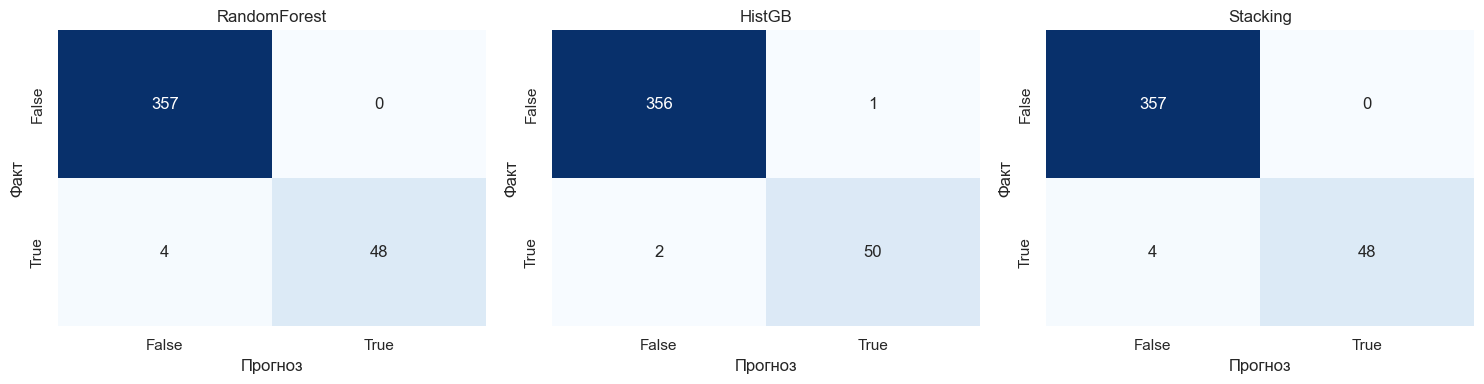

In [31]:
# Матриці помилок на test
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, [("RandomForest", best_rf), ("HistGB", best_hgb), ("Stacking", best_stack)]):
    cm = confusion_matrix(y_test, model.predict(X_test_prep))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["False", "True"], yticklabels=["False", "True"], ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Прогноз")
    ax.set_ylabel("Факт")
plt.tight_layout()
plt.show()

In [32]:
# На test усі три моделі тримають якість (навіть трохи краще за val - test невеликий, 409 рядків):
# f1 (клас True): HistGB 0.971, RandomForest і Stacking по 0.960. Найкращий - бустинг HistGB,
# у нього найвищий recall (0.962), тобто він ловить найбільше рідкісних True. Матриці помилок
# показують те саме: моделі майже не дають хибних тривог (precision ~1.0), а майже всі помилки -
# це кілька пропущених True. Різниця між train(1.0) і test невелика, а val і test схожі,
# тож схоже, що це не перенавчання, а дані справді легко розділяються.

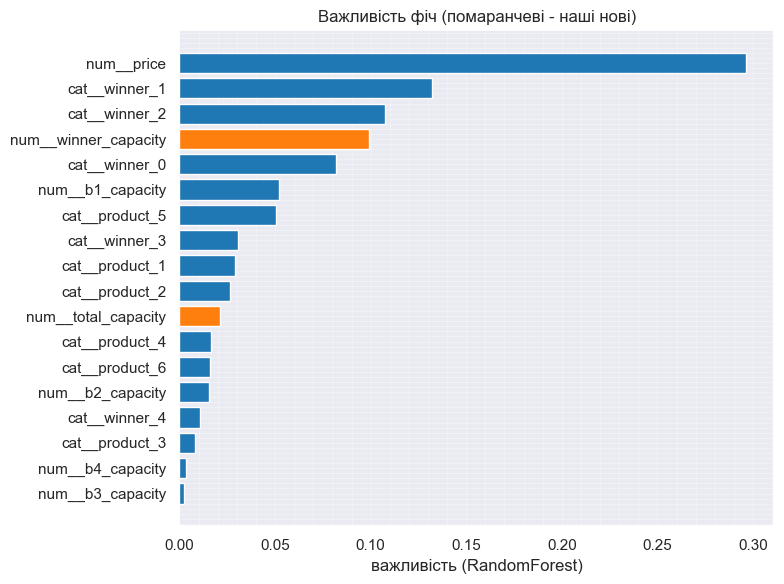

In [33]:
# Важливість фіч у налаштованому RandomForest (перевіряємо наші нові фічі)
importances = pd.Series(best_rf.feature_importances_, index=feat_names).sort_values()
plt.figure(figsize=(8, 6))
colors = ["tab:orange" if ("winner_capacity" in f or "total_capacity" in f) else "tab:blue"
          for f in importances.index]
plt.barh(importances.index, importances.values, color=colors)
plt.xlabel("важливість (RandomForest)")
plt.title("Важливість фіч (помаранчеві - наші нові)")
plt.tight_layout()
plt.show()

In [34]:
# Перевірка наших нових фіч. winner_capacity - одна з найважливіших (0.099, 4-те місце), тобто
# наша ідея "прив'язати переможця до його місткості" справдилась. total_capacity мала слабкий
# mutual information (0.007), але в лісі все одно набрала 0.021 - більше за окремі місткості
# b2/b3/b4. Тобто фіча, що сама по собі виглядала слабкою, усе ж трохи допомогла, коли дерево
# комбінує її з іншими фічами. Обидві нові фічі виявились не зайвими.

In [35]:
# Підсумок
# Класифікація verification.result (здійсненність сценарію аукціону) трьома ансамблями на
# датасеті Auction Verification. Дані незбалансовані (~13% True), тож головна метрика - f1.
# Результат на test (f1 класу True): бустинг HistGB 0.971 (найкращий), беггінг і стекінг по 0.960.